In [43]:
import matplotlib.pyplot as plt #Библиотека за визуелизација
import seaborn as sns
import numpy as np #Библиотека за нумерички анализи
import pandas as pd
from scipy import stats #Библиотека за статистички анализи
from sklearn.model_selection import train_test_split
from sklearn import datasets #Библиотека за податочни множества за машинско учење
from sklearn.preprocessing import MinMaxScaler #Min max Scaler за нормализација на податоци во опсег [0,1]
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge #Вчитување на модели за линерна регресија
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #За евалуација на модели

In [44]:
df = pd.read_csv("1553768847-housing.csv")
column_names = np.loadtxt(open("1553768847-housing.csv", "rb"), delimiter=",", max_rows=1, dtype = str)

In [45]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [46]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

In [48]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,3,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,3,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,3,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,3,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,3,342200


In [49]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

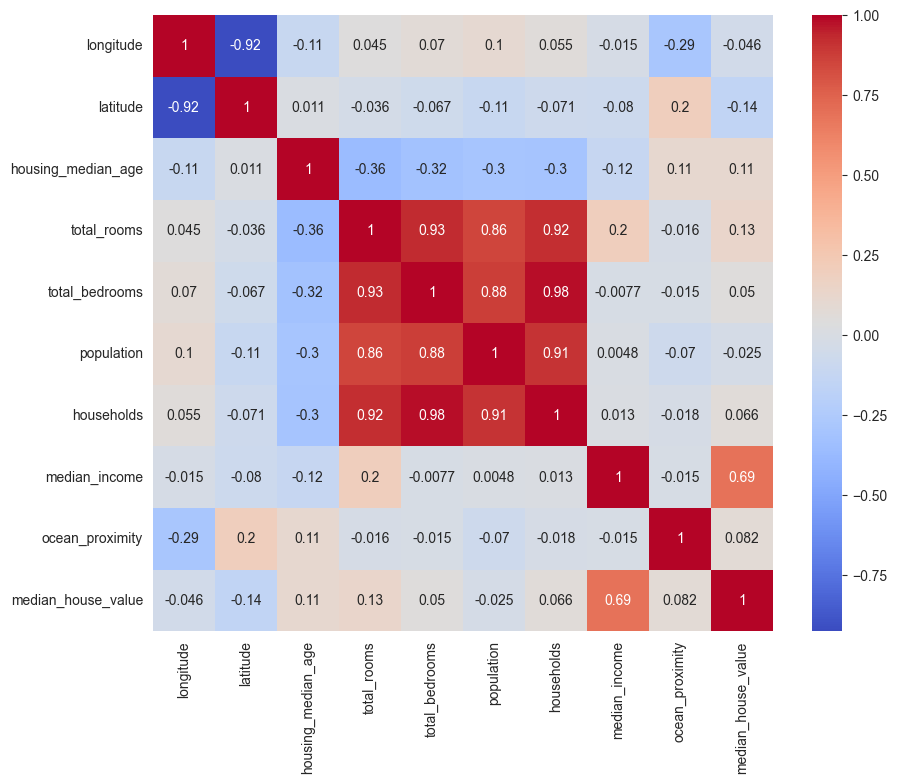

In [50]:
plt.show()
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [51]:
df=df.drop(columns=['total_bedrooms'])

In [52]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

In [53]:
X = df.iloc[:, 1:].to_numpy().astype(float)
y = df.iloc[:, 0].to_numpy().astype(float)

N = X.shape[0]
number_of_features = X.shape[1]

print(X.shape)
print(y.shape)
print("Карактеристики (Атрибути): ", column_names[:-1])
print("Број на карактеристики (атрибути):", X.shape[1]) # или number_of_features
print("Број на излезни класи: ", len(np.unique(y)))
print("Број на инстанци: ", X.shape[0]) # или N

(20640, 8)
(20640,)
Карактеристики (Атрибути):  ['longitude' 'latitude' 'housing_median_age' 'total_rooms'
 'total_bedrooms' 'population' 'households' 'median_income'
 'ocean_proximity']
Број на карактеристики (атрибути): 8
Број на излезни класи:  844
Број на инстанци:  20640


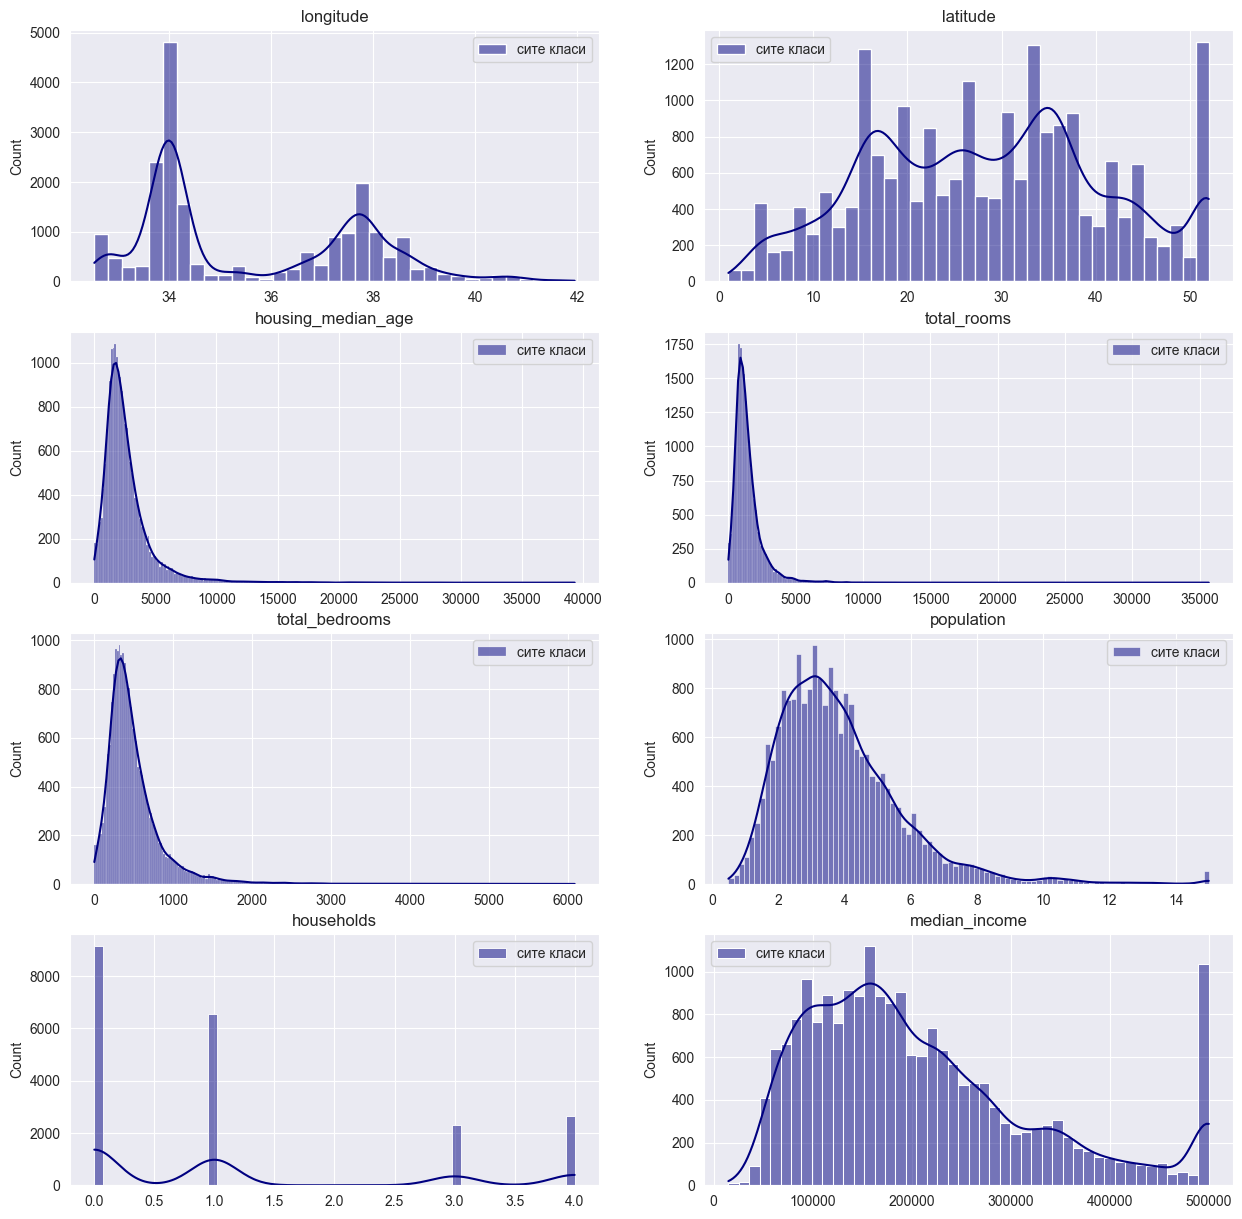

In [55]:
feature_names=column_names[:-1]
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=4, ncols=2)
for feat_i in range(number_of_features): #хистограми за секој атрибут
    ax = plt.subplot(4,2, feat_i+1)
    plt.title(feature_names[feat_i])
    sns.histplot(X[:,feat_i],color='navy',label='сите класи',kde=True,stat="count")
    plt.legend()
plt.show()

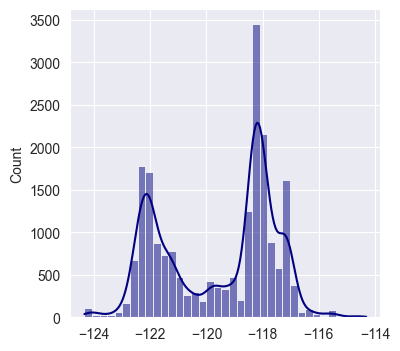

In [56]:
fig = plt.figure(figsize=(4, 4))
sns.histplot(y, color = "navy", kde=True)
plt.show()

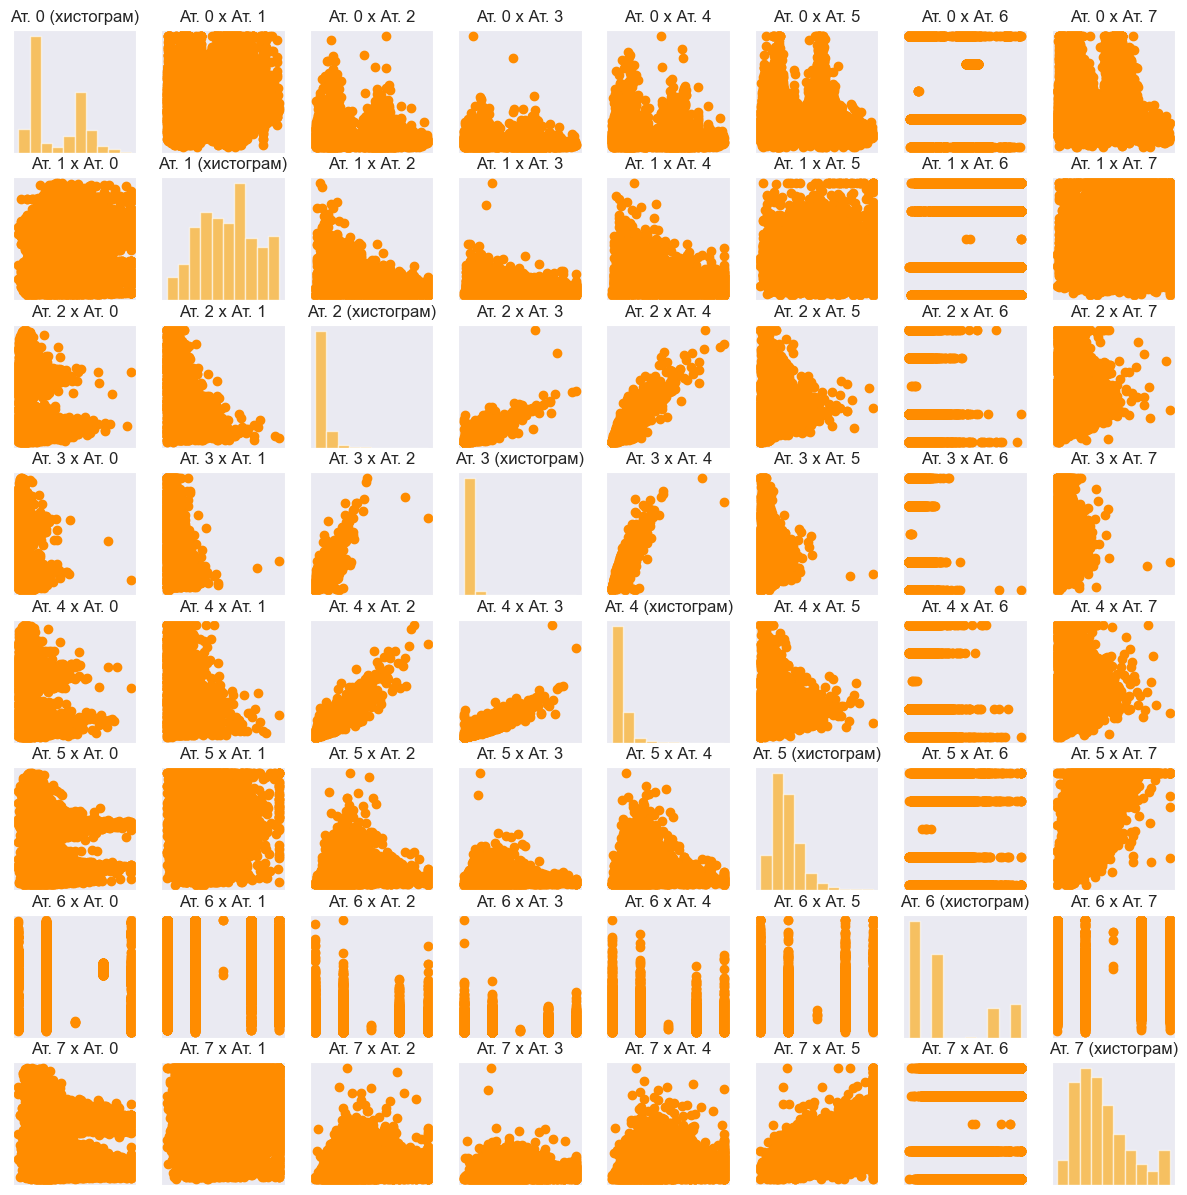

In [57]:
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
          plt.hist(X[:, feature_i], alpha=.6, color="orange")
          plt.title("Ат. "+str(feature_i)+" (хистограм)")
        else:
          plt.scatter(X[:,feature_i], X[:,feature_j], color="darkorange")
          plt.title("Ат. "+str(feature_i)+" x Ат. "+str(feature_j))
        plt.xticks(())
        plt.yticks(())
plt.show()

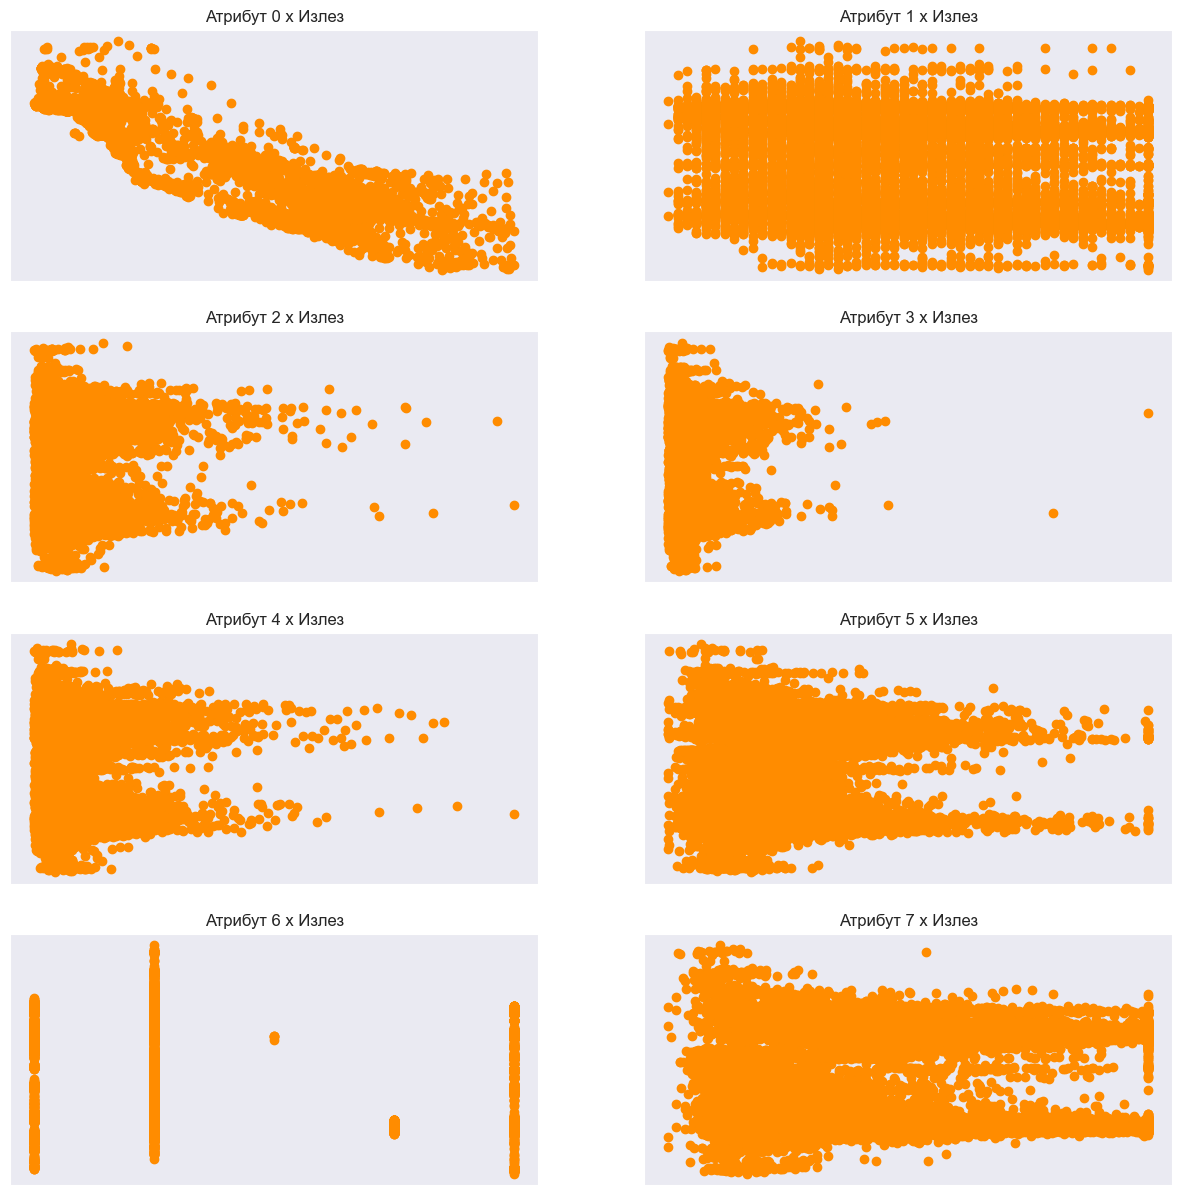

In [59]:
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=(int)(number_of_features/2),ncols=2)
for feat_i in range(number_of_features):
    ax = plt.subplot(4,2, feat_i+1)
    plt.scatter( X[:,feat_i], y, color="darkorange")
    plt.xticks(())
    plt.yticks(())
    plt.title("Атрибут "+str(feat_i)+" x Излез")
plt.show()

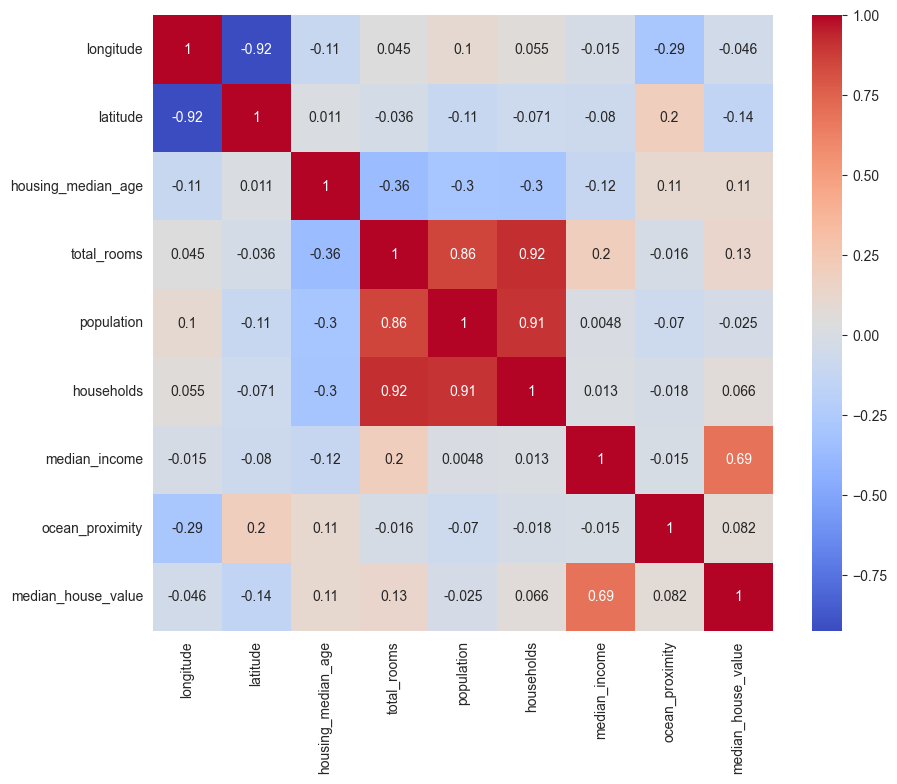

In [60]:
plt.show()
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [61]:
df=df.drop(columns=['latitude'])

In [62]:
df=df.drop(columns=['population'])

In [63]:
df=df.drop(columns=['households'])

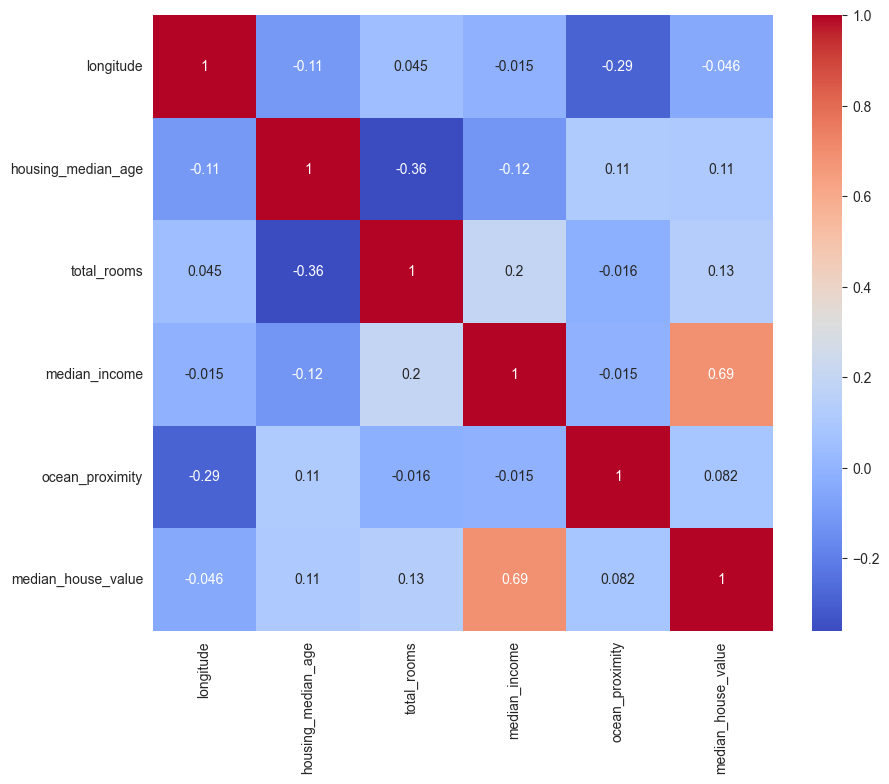

In [64]:
plt.show()
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [65]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

Коефициенти W:  [-8.34950093 -0.47256008  8.51196153 -6.70757602 -4.39162683 -0.23831452
 -0.47664708 -1.55537666]
Пресек W0:  -115.70313482622103
Средна квадратна грешка: 0.3531728851926819
Средна апсолутна грешка: 0.44231456324953805
Корен на средна квадратна грешка: 0.5942835057383655
R-квадрат:  0.9121055959326594


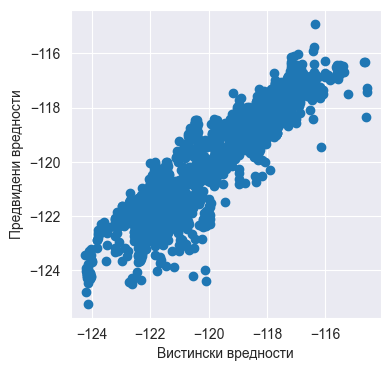

In [66]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-8.30518805 -0.49553905  6.39846629 -4.89994675 -3.48135924 -0.07256826
 -0.47081659 -1.5518815 ]
Пресек W0:  -115.75200458280861
Средна квадратна грешка: 0.3540498489080149
Средна апсолутна грешка: 0.4425364165459034
Корен на средна квадратна грешка: 0.595020881068904
R-квадрат:  0.9118873453070322


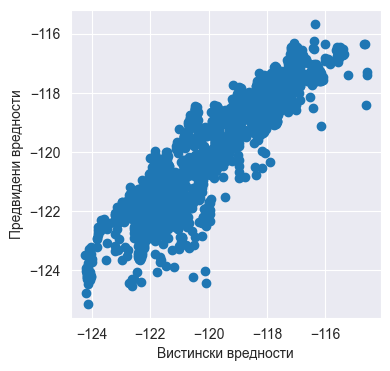

In [67]:
reg = Ridge(alpha=1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Најдобар alpha: 0.1
MSE: 0.3530730607821392
R²: 0.912130439309498


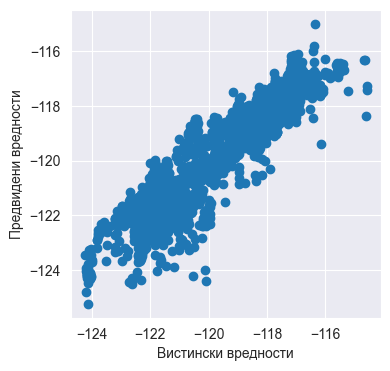

In [75]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# можни вредности за alpha
alphas = [0.01, 0.1, 1, 10, 100]

# Ridge со cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

# најдобар alpha
print("Најдобар alpha:", ridge_cv.alpha_)

# предикција
y_pred = ridge_cv.predict(X_test)

# метрики
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-6.19428772 -0.          0.          0.          0.         -0.
 -0.04123955 -0.        ]
Пресек W0:  -117.52455602148746
Средна квадратна грешка: 0.7580076506754276
Средна апсолутна грешка: 0.6971437532966155
Корен на средна квадратна грешка: 0.8706363481244208
R-квадрат:  0.8113540604957458


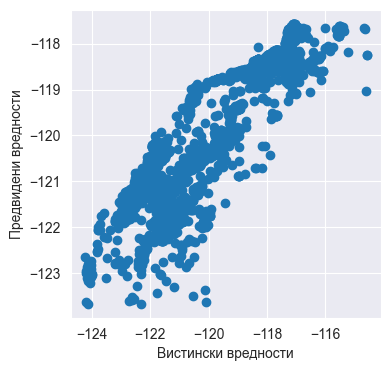

In [68]:
reg = Lasso(alpha = 0.1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Најдобар alpha: 0.001
MSE: 0.3634832571862776
R²: 0.9095396458269618


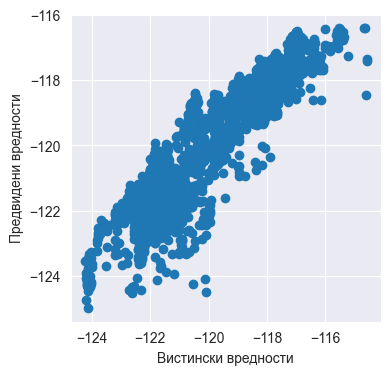

In [76]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# можни alpha вредности
alphas = [0.001, 0.01, 0.1, 1, 10]

# Lasso со cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

# најдобар alpha
print("Најдобар alpha:", lasso_cv.alpha_)

# предикција
y_pred = lasso_cv.predict(X_test)

# метрики
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-3.12640316 -0.0946066   0.          0.          0.         -0.
 -0.64032206 -0.101387  ]
Пресек W0:  -118.27460938191082
Средна квадратна грешка: 1.7234440888803464
Средна апсолутна грешка: 1.146058385319802
Корен на средна квадратна грешка: 1.3128000947898908
R-квадрат:  0.571085161158749


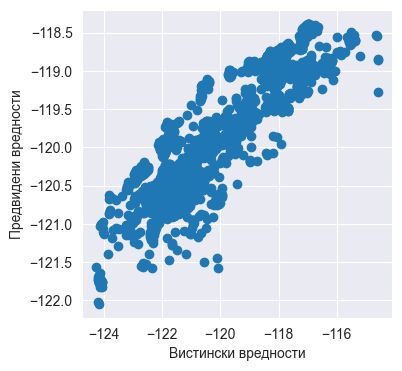

In [69]:
reg = ElasticNet(alpha = 0.1, l1_ratio = 0.3).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Коефициенти W:  [-8.34870179 -0.47300371  8.47182173 -6.67143461 -4.37523821 -0.23517328
 -0.47652309 -1.55530109]
Пресек W0:  -115.70404930955665
Средна квадратна грешка: 0.3531540540309936
Средна апсолутна грешка: 0.4423001923615918
[0.61462376 0.61473035 0.61556859 ... 0.6157713  0.61537242 0.61536215]
6192
Корен на средна квадратна грешка: 0.5942676619428265
R-квадрат:  0.9121102824581654


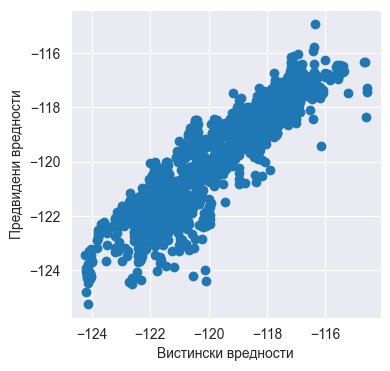

In [70]:
reg = BayesianRidge().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred, y_std = reg.predict(X_test, return_std = True) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print(y_std)
print(len(y_std))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

In [71]:
#kolku prvio feuture vlijaj na atributite

Xi=X[:,0].reshape(-1,1)
print("Xi=", Xi)
print("y=",y)

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(Xi, y) # поставете го моделот на податоците
lrsigma = np.sum((y - lr.predict(Xi))**2) /(N-2) # пресметка на варијансата на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(Xi, y)
ridgesigma = np.sum((y - ridge.predict(Xi))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(Xi, y)
lassosigma = np.sum((y - lasso.predict(Xi))**2) /(N-2)

# поставете модел на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xi, y)
elasticsigma = np.sum((y - elastic.predict(Xi))**2) /(N-2)

# поставете модел на баесова риџ регресија
Bayes = BayesianRidge()
Bayes.fit(Xi, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Регресија на еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

Xi= [[0.5674814 ]
 [0.565356  ]
 [0.5642933 ]
 ...
 [0.73219979]
 [0.73219979]
 [0.72582359]]
y= [-122.23 -122.22 -122.24 ... -121.22 -121.32 -121.24]
Коефициенти на моделите
Линеарна регресија:  [-8.16165871]
Риџ регресија:  [-8.15399079]
Ласо регресија:  [-6.22069619]
Регресија на еластична мрежа: [-3.41187768]
Баесова риџ регресија:  [-8.16159165]


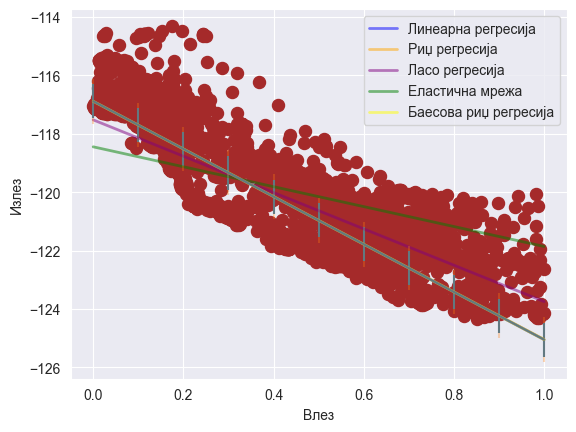

In [72]:
#Gi crta site regresioni modeli

# пресметка на линијата на секој модел во опсег [0, X.max()]
line_X = np.arange(0, 1.1, 0.1)[:, np.newaxis]
line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова риџ регресија
plt.scatter(Xi, y, color='brown', marker='.', s = 300)
plt.plot(line_X, line_y, color='blue', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y,yerr=lrsigma)
plt.plot(line_X, line_y_ridge, color='orange', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='purple', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color="green", linewidth=lw, label='Eластичнa мрежa', alpha=0.5)
plt.plot(line_X, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

Обликот на X:  (20640, 1)
Обликот на трансформираната матрица Xt (20640, 2)
(20640, 2)
(20640,)
Коефициенти на моделите
Линеарна регресија:  [-13.2822018    6.71195387]
Риџ регресија:  [-12.93224602   6.26917648]
Ласо регресија:  [-6.22069619 -0.        ]
Еластична мрежа: [-2.80184594 -1.73096163]
Баесова риџ регресија:  [-13.28054471   6.70985608]
[[0.   0.  ]
 [0.1  0.01]
 [0.2  0.04]
 [0.3  0.09]
 [0.4  0.16]
 [0.5  0.25]
 [0.6  0.36]
 [0.7  0.49]
 [0.8  0.64]
 [0.9  0.81]
 [1.   1.  ]]


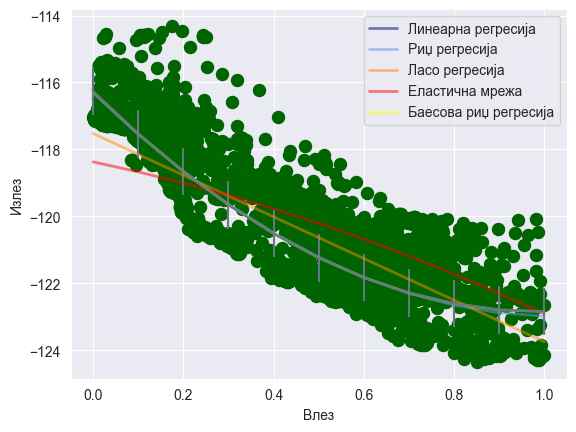

In [73]:
p = np.array([1, 2]) # за едноставен еднодимензионален случај, можеме да направиме проширување на основната функција вака
Xt = Xi ** p # забележете дека Xt сега има две карактеристики (едната претставува X, а другата претставува X^2)
print("Обликот на X: ", Xi.shape)
print("Обликот на трансформираната матрица Xt", Xt.shape)

print(Xt.shape)
print(y.shape)

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(Xt, y) # поставете го моделот на податоците
lrsigma = np.sqrt(np.sum((y - lr.predict(Xt))**2) /(N-2)) # пресметка на варијанската на моделот

# поставете модел на риџ регресија
ridge = Ridge(alpha=1)
ridge.fit(Xt, y)
ridgesigma = np.sum((y - ridge.predict(Xt))**2) /(N-2)

# поставете модел на ласо регресија
lasso = Lasso(alpha=0.1)
lasso.fit(Xt, y)
lassosigma = np.sum((y - lasso.predict(Xt))**2) /(N-2)

# поставете модел на регресија на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xt, y)
elasticsigma = np.sum((y - elastic.predict(Xt))**2) /(N-2)

# поставете модел на баесовa риџ регресија
Bayes = BayesianRidge()
Bayes.fit(Xt, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

# пресметка на линијата на секој модел во опсег [0, X1.max()]
line_X0 = np.arange(0, 1.1, 0.1)[:, np.newaxis]
line_X1 = line_X0*line_X0
line_X = np.concatenate((line_X0,line_X1),1)
print(line_X)
line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

M=line_X1.size
lrsigma_array=np.ones(M)*lrsigma

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова риџ регресија
plt.scatter(Xi, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X0, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X0, line_y.flatten(), yerr=lrsigma_array)
plt.plot(line_X0, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X0, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X0, line_y_elastic, color="red", linewidth=lw, label='Еластична мрежа', alpha=0.5)
plt.plot(line_X0, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X0, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()